# 📞 Calls dataset — EDA and preprocessing

Copenhagen Networks Study, `calls.csv`: phone-call metadata with columns
`timestamp`, `caller`, `callee`, `duration`.

Per `calls.README`, **`duration == -1` is a documented sentinel for a missed
call** — it is not a missing value and must never be imputed or dropped as
one.

Steps covered (see the course checklist): **(1) duplicates → (2) missing
data → (3) outliers → (4) scaling**. Reusable logic lives in
`src/features/eda.py` so these decisions can be reused by the other
per-dataset notebooks instead of being copy-pasted.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.io import load_telecom_data
from src.features import eda

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "7267433" / "calls.csv"
%matplotlib inline

## Load

`load_telecom_data(..., log_type="calls")` (`src/data/io.py`) already adds the
`is_missed_call` flag from the `duration == -1` sentinel — reused here rather
than re-implemented.

In [2]:
data = load_telecom_data(RAW_PATH, log_type="calls")
print(data.shape)
data.head()

(3600, 5)


,timestamp,caller,callee,duration,is_missed_call
0,184,300,301,121,False
1,3920,512,299,670,False
2,5623,301,300,504,False
3,9252,401,457,-1,True
4,15466,512,0,5,False


In [3]:
data.dtypes

timestamp         int64
caller            int64
callee            int64
duration          int64
is_missed_call     bool
dtype: object

## (1) Duplicates

Two kinds of duplication matter here: **exact duplicate rows** (the same
call record appears twice — a loading/logging artifact) and **duplicate
business keys** (same `timestamp`+`caller`+`callee` with a different
`duration` — a genuine data-quality conflict, not just redundancy).

In [4]:
exact = eda.duplicate_report(data)
business_key = eda.duplicate_report(data, subset=["timestamp", "caller", "callee"])
exact, business_key

({'n_rows': 3600, 'n_duplicate_rows': 0, 'pct_duplicate_rows': 0.0},
 {'n_rows': 3600, 'n_duplicate_rows': 0, 'pct_duplicate_rows': 0.0})

**Decision:** both counts are `0` — there is nothing to drop. The code
path is still wired through `eda.drop_duplicate_rows` (rather than skipped)
so it activates automatically if a future data refresh introduces
duplicates.

In [5]:
data = eda.drop_duplicate_rows(data)
len(data)

3600

## (2) Missing data

Check true missingness (`NaN`) per column first, independently of the
`duration == -1` sentinel.

In [6]:
eda.missingness_report(data)

,n_missing,pct_missing
timestamp,0,0.0
caller,0,0.0
callee,0,0.0
duration,0,0.0
is_missed_call,0,0.0


**Decision:** every column has `0` true `NaN`s, so no imputer is
needed here.

This is the important contrast with the course's `RoofSurface` exercise:
there, `NaN` really meant "unknown" and warranted a documented
drop/impute/flag choice. Here, the closest thing to "missing" is
`duration == -1`, but that is a **coded category** (missed call), not an
unknown value — reusing `SimpleImputer(strategy="median")` on it would
silently fabricate call durations for calls that never connected. It is
already captured correctly as `is_missed_call`, so no missing-data strategy
is applied to `duration`.

In [7]:
data["is_missed_call"].value_counts(normalize=True) * 100

is_missed_call
False    89.833333
True     10.166667
Name: proportion, dtype: float64

## (3) Outliers

`duration` is the only real numeric measurement. Missed calls (`duration ==
-1`) must be excluded before computing quartiles/IQR, otherwise the sentinel
would distort the bounds for every other call.

In [8]:
completed_calls = data.loc[~data["is_missed_call"]]
outlier_bounds = eda.outlier_report_iqr(completed_calls, "duration")
outlier_bounds

{'column': 'duration',
 'q1': 2.0,
 'q3': 57.0,
 'iqr': 55.0,
 'lower_bound': -80.5,
 'upper_bound': 139.5,
 'n_outliers': 321,
 'pct_outliers': 9.9258}

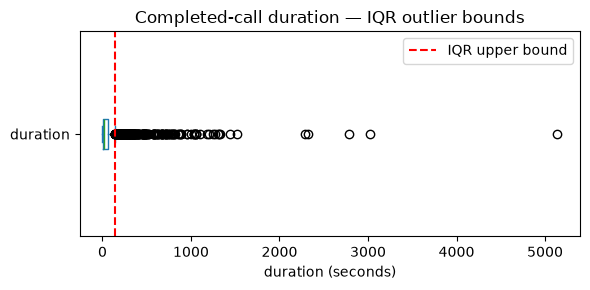

In [9]:
fig, ax = plt.subplots(figsize=(6, 3))
completed_calls["duration"].plot(kind="box", vert=False, ax=ax)
ax.set_xlabel("duration (seconds)")
ax.set_title("Completed-call duration — IQR outlier bounds")
ax.axvline(outlier_bounds["upper_bound"], color="red", linestyle="--", label="IQR upper bound")
ax.legend()
fig.tight_layout()

**Decision:** ~10% of completed calls fall above the IQR upper bound
(long calls, up to ~5,138s ≈ 85 minutes). These are flagged, not dropped —
a long phone call is a plausible campus-life behavior, not a measurement
error, and dropping these rows would bias any downstream
communication-volume feature. `duration_outlier` is only computed over
completed calls; missed calls keep the flag unset (`False`).

In [10]:
data["duration_outlier"] = False
data.loc[completed_calls.index, "duration_outlier"] = eda.flag_outliers_iqr(
    completed_calls, "duration"
)["duration_outlier"]
data["duration_outlier"].value_counts()

duration_outlier
False    3279
True      321
Name: count, dtype: int64

## (4) Scaling

Only `duration` is a magnitude worth scaling. `timestamp`, `caller`, and
`callee` are never scaled: `caller`/`callee` are anonymous categorical
participant IDs (per the project's Bluetooth-data rule, IDs are never
treated as numerical measurements), and `timestamp` is a temporal key, not a
feature magnitude.

Scaling is fit on completed calls only, so the `-1` sentinel does not pull
the median/IQR away from real call durations. `duration_outlier` (~9.93%
flagged above) is kept, not dropped, so `RobustScaler` is used instead of
`StandardScaler`/`MinMaxScaler` — it centers on the median and scales by
the IQR, so the flagged long calls do not distort the scale for everyone
else.

In [11]:
completed_calls = data.loc[~data["is_missed_call"]]
scaled_completed, duration_scaler = eda.scale_numeric_columns(
    completed_calls, ["duration"], method="robust"
)

data["duration_scaled"] = pd.NA
data.loc[scaled_completed.index, "duration_scaled"] = scaled_completed["duration_scaled"]
data[["duration", "is_missed_call", "duration_scaled"]].head(10)

,duration,is_missed_call,duration_scaled
0,121,False,1.909091
1,670,False,11.890909
2,504,False,8.872727
3,-1,True,<NA>
4,5,False,-0.2
5,28,False,0.218182
6,619,False,10.963636
7,11,False,-0.090909
8,74,False,1.054545
9,20,False,0.072727


## (5)/(6) Balancing & encoding — not applicable here

No column here is a classification target, so there is nothing to
balance. The only categorical-looking columns are `caller`/`callee`
(anonymous **nominal** participant IDs — no inherent order, so an ordinal
encoder would fabricate a false ranking between people) and
`is_missed_call`, which is already a binary flag — exactly what an
encoder would produce for a two-category column anyway.

## Result

`data` is now the prepared dataframe for `calls.csv`:

- 0 duplicate rows, 0 true missing values (verified, not assumed).
- `duration == -1` kept as the documented sentinel, exposed via
  `is_missed_call` — never imputed.
- `duration_outlier` flags long completed calls instead of dropping them.
- `duration_scaled` holds the median/IQR-scaled (`RobustScaler`) duration
  for completed calls (`NA` for missed calls, consistent with the sentinel
  never being treated as a real duration) — chosen over `StandardScaler`
  because the flagged long-call outliers are kept, not dropped.

Saved separately from the raw pass-through `calls.parquet` produced by
`main.py`/`export_secondary_datasets`, so this prepared version does not
silently change the existing pipeline's output until the two are
reconciled on purpose.

In [12]:
from src.data.io import write_processed_data

output_path = write_processed_data(data, PROJECT_ROOT / "data" / "processed", "calls_prepared.parquet")
output_path

PosixPath('/home/johnny/master_uu/UU-DataMining-2026/data/processed/calls_prepared.parquet')